# Check fitness of starting coefficients

In [28]:
import os
import polars as pl
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

## Load admissions data

In [29]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [30]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the age proportions:

In [31]:
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [32]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

SSNAP coefficients and population data:

In [33]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [34]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [35]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

Pick out admissions numbers:

In [36]:
dict_admissions_age = dict(zip(df_pop_admissions['Age Groups'], df_pop_admissions['admissions_annual_boost']))

admissions_by_age = list(dict_admissions_age.values())

dict_admissions_age

{'Under 65': 18737.66819,
 '65-69': 7395.26689,
 '70-74': 10379.62674,
 '75-79': 11654.63948,
 '80 and over': 32790.7987}

## Parameter setup

Which values are allowed for each coefficient?


Set up options for how much the SSNAP coefficients can be scaled by:

In [37]:
scale_options = np.round(np.arange(0.2, 2.01, 0.1), 1)

scale_options

array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4,
       1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

The following code is useful for more than 5 deprivation quantiles when it is too difficult to store every combo and then remove unpromising ones:

The following code runs ok for 5 deprivation quantiles. 

It calculates all possible combinations of scale factors and then selectively keeps only the sensible options.

In [38]:
scale_option_combos = np.array([s for s in product(scale_options, repeat=5)])
print(len(scale_option_combos))

# Only keep combos where scales decrease/stay same with depriv quantile
# (i.e. scale is larger when deprivation higher):
mask = (np.diff(scale_option_combos, axis=1) <= 0.0).all(axis=1)
scale_option_combos = scale_option_combos[mask]
print(len(scale_option_combos))

# When all coeffs are 1, the sum of coeffs is 5.
# Only keep combinations where the sum is reasonably near 5,
# e.g. reject 0.2, 0.2, 0.2, 0.2, 0.2 (sum 1)
# and 2.0, 2.0, 2.0, 2.0, 2.0 (sum 10).
mask = (scale_option_combos.sum(axis=1) >= 4) & (scale_option_combos.sum(axis=1) <= 6)
scale_option_combos = scale_option_combos[mask]
print(len(scale_option_combos))

# Remove combos where most values are very high or very low, i.e. only
# keep combos where no more than two values are under 1.0 or
# no more than two values are over 1.0.
# Because of the forced increasing order of coefficients,
# this mask results in the middle coefficient always being 1.0. 
mask = ((scale_option_combos < 1.0).sum(axis=1) < 3) & ((scale_option_combos > 1.0).sum(axis=1) < 3)
scale_option_combos = scale_option_combos[mask]
print(len(scale_option_combos))

2476099
33649
17418
2659


In [39]:
scale_option_combos[:5]

array([[1. , 1. , 1. , 0.5, 0.5],
       [1. , 1. , 1. , 0.6, 0.4],
       [1. , 1. , 1. , 0.6, 0.5],
       [1. , 1. , 1. , 0.6, 0.6],
       [1. , 1. , 1. , 0.7, 0.3]])

In [40]:
scale_option_combos[-5:]

array([[2. , 2. , 1. , 0.6, 0.3],
       [2. , 2. , 1. , 0.6, 0.4],
       [2. , 2. , 1. , 0.7, 0.2],
       [2. , 2. , 1. , 0.7, 0.3],
       [2. , 2. , 1. , 0.8, 0.2]])

Set up SSNAP coefficients:

In [41]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

Set up all combos of starting coefficients:

In [42]:
# Store start combos of coeffs in here:
coeffs_init_start = {}

for s, scale_options_here in enumerate(scale_option_combos):
    coeffs_init = list(np.round(np.concatenate([np.ones(5) * s for s in scale_options_here]), 8))
    coeffs_init_start[s] = coeffs_init

In [43]:
df_coeffs_init = pl.concat([pl.DataFrame([c], schema=coeff_names) for c in coeffs_init_start.values()]).cast(float)

df_coeffs_init = df_coeffs_init.with_columns(pl.Series('coeff_combo', coeffs_init_start.keys()).cast(int))
# Move this column to start:
df_coeffs_init = df_coeffs_init.drop('coeff_combo').insert_column(0, df_coeffs_init.get_column('coeff_combo'))

/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


In [44]:
df_coeffs_init.head()

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.6,0.6,0.6,0.6,0.6,0.4,0.4,0.4,0.4,0.4
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.6,0.6,0.6,0.6,0.6,0.5,0.5,0.5,0.5,0.5
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.7,0.7,0.7,0.7,0.7,0.3,0.3,0.3,0.3,0.3


## Set up fitness evaluation

In [45]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [46]:
def predict_admissions_each_age(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (
        [(x_lists[i] * coeffs[i]).sum() for i in range(len(coeffs))]
    )
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [47]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (np.array(yhat) - np.array(y))**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return np.sqrt(sum_sqres)

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [48]:
# def find_mean_abs_diff(yhat, y):
#     # Difference from actual:
#     absres = np.abs((yhat - y))
#     # Mean of differences:
#     mean_absres = absres.mean()
#     return mean_absres

Goodness check option 3: This calculates the sum of the ratio of the error to each observed number of strokes:

In [49]:
# def find_err_ratios(yhat, y):
#     # Difference from actual:
#     sqres = np.abs(np.array(yhat) - np.array(y)) / np.array(y)
#     # Sum of differences:
#     sum_sqres = sqres.sum()
#     return sum_sqres

To check accuracy, the following function calculates R-squared:

In [50]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y = np.array(y)
    yhat = np.array(yhat)
    y_mean = np.mean(y)#.mean()
    ss_res = np.sum(((yhat - y)**2.0))#.sum()
    ss_tot = np.sum(((y - y_mean)**2.0))#.sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

In [51]:
# the goal ('fitness') function to be maximized
def eval_admissions(coeffs_ssnap, admissions_lists, x_lists, admissions_by_age, individual):

    # Predictions for each age band across England:
    predictions_by_age = [0.0] * 5
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5] * np.array(coeffs_ssnap)
        yhat_list = predict_admissions_each_age(x_lists_here, coeffs)
        # predictions_lists.append(yhat)
        for j, y in enumerate(yhat_list):
            predictions_by_age[j] += y
    # Divide the admissions by age band by the observed values:
    for j in range(len(predictions_by_age)):
        predictions_by_age[j] /= admissions_by_age[j]
    # Wrongness ratio factor:
    rat = sum(np.abs(np.array(predictions_by_age) - 1.0)) + 1.0
    
    # Predictions for each MSOA:
    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5] * np.array(coeffs_ssnap)
        yhat = predict_admissions(x_lists_here, coeffs)
        predictions_lists.append(yhat)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Use only one of the following options for checking the fit:
    sum_sqres = find_square_residuals(predicted_all, observed_all)
    # sum_sqres = find_err_ratios(predicted_all, observed_all)
    # sum_sqres = find_mean_abs_diff(yhat, admissions)

    # Apply wrongness factor:
    # sum_sqres *= rat
    
    return (sum_sqres, rat, sum_sqres * rat)

Gather data for use with the evaluation function:

In [52]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

## Calculate fitnesses

In [53]:
cols_coeffs = [c for c in df_coeffs_init.columns if c != 'coeff_combo']
# Keep a copy of just one age column since all the values are repeated here:
cols_less65 = [c for c in cols_coeffs if 'less65' in c]

In [54]:
cols_coeffs

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

Calculate admissions for each age band:

In [55]:
sum_sqres_list = []
wrongness_rat_list = []
fitness_list = []

for coeff_combo in df_coeffs_init['coeff_combo']:
    print(f'Combo {coeff_combo+1:6d} of {len(df_coeffs_init)}', end='\r')
    coeffs_here = df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == coeff_combo)[cols_coeffs].to_numpy()[0]
    sum_sqres, wrongness_rat, fitness = eval_admissions(coeffs_ssnap, admissions_lists, x_lists, admissions_by_age, coeffs_here)
    sum_sqres_list.append(round(sum_sqres, 1))
    wrongness_rat_list.append(round(wrongness_rat, 3))
    fitness_list.append(round(fitness, 1))

In [56]:
df_coeffs_init = df_coeffs_init.with_columns(pl.Series('sum_sqres', sum_sqres_list))
df_coeffs_init = df_coeffs_init.with_columns(pl.Series('wrongness_rat', wrongness_rat_list))
df_coeffs_init = df_coeffs_init.with_columns(pl.Series('fitness', fitness_list))

In [57]:
df_coeffs_init.sort('fitness')

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrongness_rat,fitness
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
177,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,239.2,1.059,253.2
301,1.3,1.3,1.3,1.3,1.3,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.8,0.8,0.8,0.8,0.8,240.0,1.066,255.8
259,1.3,1.3,1.3,1.3,1.3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,242.3,1.058,256.4
184,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.8,0.8,0.8,0.8,0.8,243.1,1.059,257.4
176,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.8,0.8,0.8,0.8,0.8,239.9,1.075,257.9
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
356,1.3,1.3,1.3,1.3,1.3,1.3,1.3,1.3,1.3,1.3,1.0,1.0,1.0,1.0,1.0,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,556.3,2.255,1254.3
487,1.4,1.4,1.4,1.4,1.4,1.2,1.2,1.2,1.2,1.2,1.0,1.0,1.0,1.0,1.0,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,553.8,2.265,1254.4
666,1.5,1.5,1.5,1.5,1.5,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,556.9,2.276,1267.2


In [58]:
df_coeffs_init[['sum_sqres', 'wrongness_rat', 'fitness']].min()

sum_sqres,wrongness_rat,fitness
f64,f64,f64
239.2,1.053,253.2


In [59]:
df_coeffs_init[['sum_sqres', 'wrongness_rat', 'fitness']].max()

sum_sqres,wrongness_rat,fitness
f64,f64,f64
723.1,2.286,1292.7


Check fitness values:

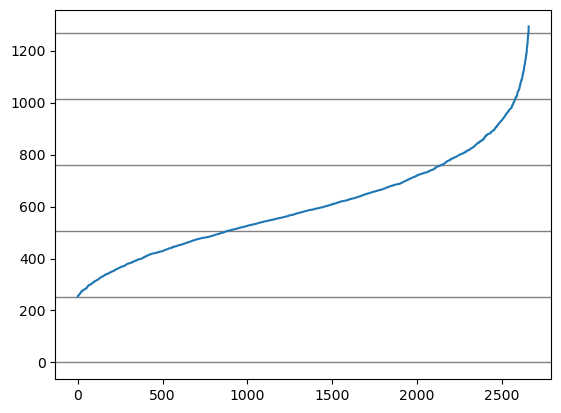

In [60]:
best_fitness = df_coeffs_init['fitness'].min()

fig, ax = plt.subplots()
ax.plot(df_coeffs_init.sort('fitness')['fitness'])
for i in np.arange(0.0, ax.get_ylim()[1], best_fitness):
    ax.axhline(i, linewidth=1.0, color='grey', zorder=0)
plt.show()

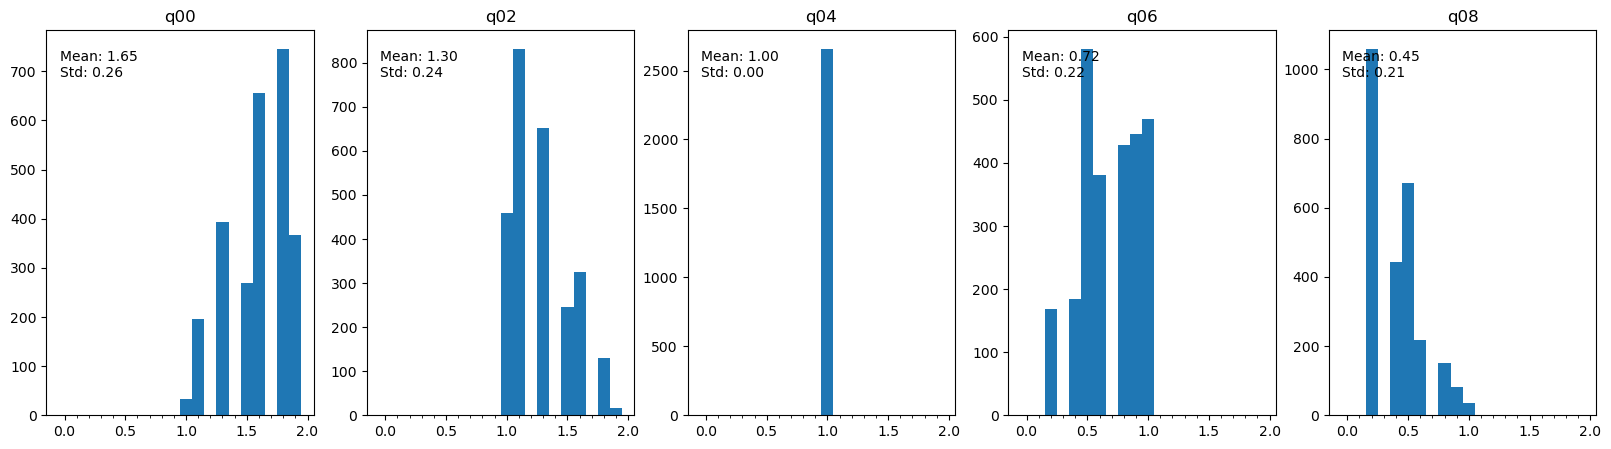

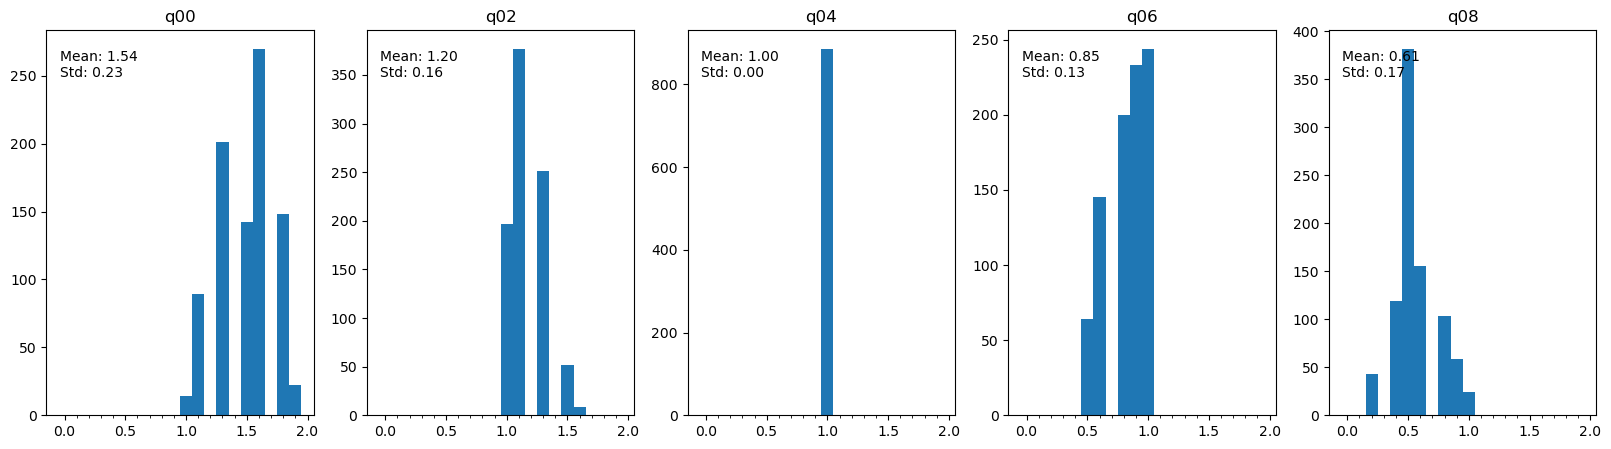

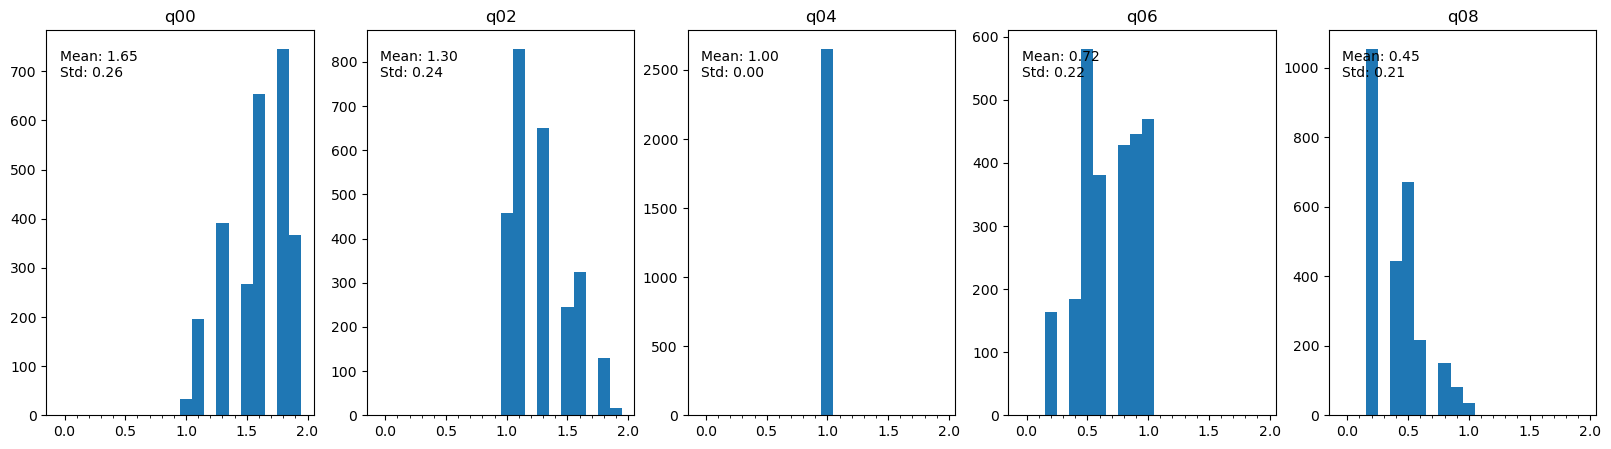

In [61]:
dfs_for_hist = [
    df_coeffs_init,
    df_coeffs_init.filter(df_coeffs_init['fitness'] <= df_coeffs_init['fitness'].min() * 2.0),
    df_coeffs_init.filter(df_coeffs_init['fitness'] <= df_coeffs_init['fitness'].min() + 1000.0),
]

for df in dfs_for_hist:
    
    # Build histograms:
    hist_dict = {}
    
    bin_max = df[cols_less65].max().to_numpy().max()
    bins = np.arange(0.0, bin_max+0.1, 0.1)  # for final bin right hand edge
    
    for c, coeff in enumerate(cols_less65):
        hist, bins = np.histogram(df[coeff], bins=bins)
        hist_dict[coeff] = hist
    
    # Plot histograms:
    fig, axs = plt.subplots(1, 5, figsize=(20, 5))
    
    for c, coeff in enumerate(cols_less65):
        ax = axs[c]#c // 5, c % 5]
        ax.set_title(coeff.split('_')[-1])
        ax.bar(bins[:-1], hist_dict[coeff], width=0.1)
        label = df[coeff].mean()
        label_std = df[coeff].std()
        ax.annotate(f'Mean: {label:.2f}\nStd: {label_std:.2f}', xy=(0.05, 0.95), va='top', ha='left', xycoords='axes fraction')
        ax.set_xticks(bins[:-1], minor=True)
    plt.show()

In [62]:
df_coeffs_init.filter(df_coeffs_init['fitness'] <= df_coeffs_init['fitness'].min() * 2.0).sort('fitness')

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrongness_rat,fitness
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
177,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,239.2,1.059,253.2
301,1.3,1.3,1.3,1.3,1.3,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.8,0.8,0.8,0.8,0.8,240.0,1.066,255.8
259,1.3,1.3,1.3,1.3,1.3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,242.3,1.058,256.4
184,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.8,0.8,0.8,0.8,0.8,243.1,1.059,257.4
176,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.8,0.8,0.8,0.8,0.8,239.9,1.075,257.9
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1420,1.7,1.7,1.7,1.7,1.7,1.4,1.4,1.4,1.4,1.4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.4,0.4,0.4,0.4,0.4,396.2,1.277,505.8
348,1.3,1.3,1.3,1.3,1.3,1.2,1.2,1.2,1.2,1.2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.3,0.3,0.3,0.3,0.3,376.4,1.344,506.0
1153,1.6,1.6,1.6,1.6,1.6,1.5,1.5,1.5,1.5,1.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.3,0.3,0.3,0.3,0.3,430.4,1.176,506.0


In [63]:
df_coeffs_init.filter(df_coeffs_init['fitness'] <= df_coeffs_init['fitness'].min() + 100.0).sort('fitness')

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrongness_rat,fitness
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
177,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,239.2,1.059,253.2
301,1.3,1.3,1.3,1.3,1.3,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.8,0.8,0.8,0.8,0.8,240.0,1.066,255.8
259,1.3,1.3,1.3,1.3,1.3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,0.9,242.3,1.058,256.4
184,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.8,0.8,0.8,0.8,0.8,243.1,1.059,257.4
176,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.8,0.8,0.8,0.8,0.8,239.9,1.075,257.9
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
174,1.2,1.2,1.2,1.2,1.2,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.9,0.9,0.6,0.6,0.6,0.6,0.6,272.0,1.294,351.9
1046,1.6,1.6,1.6,1.6,1.6,1.3,1.3,1.3,1.3,1.3,1.0,1.0,1.0,1.0,1.0,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,315.2,1.117,352.0
467,1.4,1.4,1.4,1.4,1.4,1.1,1.1,1.1,1.1,1.1,1.0,1.0,1.0,1.0,1.0,0.8,0.8,0.8,0.8,0.8,0.6,0.6,0.6,0.6,0.6,283.4,1.242,352.1


## Save results

In [64]:
print(stop, here, please)

NameError: name 'stop' is not defined

In [ ]:
df_coeffs_init.write_csv(os.path.join('outputs', 'multi_deap_coeffs_init.csv'))

In [ ]:
df_coeffs_init = pl.read_csv(os.path.join('outputs', 'multi_deap_coeffs_init.csv'))